# Project description:

Dr. Zeus has gathered some data from 1000 patients that have diabetes in a timespan of a year. The data has several columns depicting various information regarding how they are managing their condition. 

- 'Kolku dolgo e dijabeticar' - a column depicting (in years) the length of the condition that the patient has had,


- 'Kolku mu e tromesechen (hemoglobin A1C) she4er' - a column depicting the last measured value of the hemoglobin A1C sugar levels every three months., 


- 'Dali e na insulin ili na tabli?' - information whether a patient is on insulin (value 1) or tablets (value 0), 


- 'Glukoza (momentalna) vo krv' - information about current glucose level, 


- 'Dali ima dijabetesna retinopatija?' - information whether the patient has (value 1) or does not have (value 0) diabetic retinopathy.

    ## What needs to be done?


- 1. In the Drive folder you have a dataset 'Diabetes_data.csv', read the dataset into Pandas.


- 2. The data is slopily gathered and you need to rename, correct, and handle missing values. Check to see if any of the columns have null/missing values and determine the best strategy for cleaning up the data (including not doing anything). ..........(3 points total)


- 3. Find the patient which currently has the highest glucose level. Sketch (on a plot of your choice) all of the patients glucose levels and describe the plot. Draw a conclusion on how the data behaves. .......... (3 points)


- 4. Find the average number of hemoglobin A1C levels of patients per length of disease. Which duration of the disease has the highest average glucose levels? Sketch the data on a plot of your choice to best describe the data. Write a sentence or two describing how the data behaves.   .......... (3 points)


- 5. Find the average duration of the disease for patients that are on insulin and patients that are on tablets. Compare the results. Which method that the patients use shows better results? .......... (3 points)


- 6. A normal hemoglobin A1C glucose level is below 5.7. Divide the data in 2 groups (patients that have normal A1C level and patients that have elevated A1C level), then sketch the data using a plot of your choice dependent on the length of the disease. Distinguishing both groups. .......... (4 points)


- 7. How do factors influence the outcome whether a patient will have (or not) diabetic retinopathy? Analyse whether there is a correlation or not between diabetic retinopathy and other data in the set. Do this by separating the patients into 2 groups and analyzing the characteristics of the groups with respect to various information. Plot various data points if possible. .......... (4 points)

---

### Libraries:

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime 
from decimal import Decimal 

---

### 1. In the Drive folder you have a dataset 'Diabetes_data.csv', read the dataset into Pandas.

In [31]:
df = pd.read_csv('C:\\Users\\User\\Desktop\\New folder\\Numpy n Pandas\\01 Medicine Scenario\\Diabetes_data.csv')
df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

---

### 2. The data is slopily gathered and you need to rename, correct, and handle missing values. Check to see if any of the columns have null/missing values and determine the best strategy for cleaning up the data (including not doing anything).

In [32]:
df.rename(columns = {'Unnamed: 0' : 'ID'}, inplace = True)
df.rename(columns = {'Kolku dolgo e dijabeticar' : 'DolzinaDijabet'}, inplace = True)
df.rename(columns = {'Kolku mu e tromesechen (hemoglobin A1C) she4er' : 'Tromesecen_A1C'}, inplace = True)
df.rename(columns = {'Dali e na insulin ili na tabli?' : 'Ins_Tab'}, inplace = True)
df.rename(columns = {'Glukoza (momentalna) vo krv' : 'Nivo_Glukoza'}, inplace = True)
df.rename(columns = {'Dali ima dijabetesna retinopatija?' : 'DijabetRetin'}, inplace = True)

In [1]:
df['DolzinaDijabet'] = df['DolzinaDijabet'].fillna(df['DolzinaDijabet'].mean())
df['Tromesecen_A1C'] = df['Tromesecen_A1C'].fillna(df['Tromesecen_A1C'].mean())
df['Ins_Tab'] = df['Ins_Tab'].fillna(df['Ins_Tab'].mode()[0])
df['Nivo_Glukoza'] = df['Nivo_Glukoza'].fillna(df['Nivo_Glukoza'].mean())
df['DijabetRetin'] = df['DijabetRetin'].fillna(df['DijabetRetin'].mode()[0])
df['DolzinaDijabet'] = df['DolzinaDijabet'].astype(int)
df['Tromesecen_A1C'] = df['Tromesecen_A1C'].round(decimals = 2)
df['Nivo_Glukoza'] = df['Nivo_Glukoza'].round(decimals = 2)


df

### 3. Find the patient which currently has the highest glucose level. Sketch (on a plot of your choice) all of the patients glucose levels and describe the plot. Draw a conclusion on how the data behaves.

In [34]:
df['Nivo_Glukoza'].idxmax() # THE PATIENT ID WITH THE HIGHEST GLUCOSE LEVEL IN THE DATASET

664

In [35]:
df['Nivo_Glukoza'].max() # NAJVISOKO NIVO NA GLUKOZA VO DATAFRAMOT

12.6

In [2]:
df.plot(kind = 'scatter', x = 'ID', y = 'Nivo_Glukoza', figsize = (12,5))
plt.show()

# MOST OF THE PATIENT'S GLUCOSE LEVEL IS IN THE 5-7 RANGE

---

### 4. Find the average number of hemoglobin A1C levels of patients per length of disease. Which duration of the disease has the highest average glucose levels? Sketch the data on a plot of your choice to best describe the data. Write a sentence or two describing how the data behaves.

In [3]:
df.groupby(df['DolzinaDijabet'])['Tromesecen_A1C'].mean().plot(kind = 'line', rot = 1, 
linewidth = 5, figsize = (12,5))
plt.show()

# HIGHEST AVERAGE GLUCOSE LEVELS ARE AMONG PATIENTS WITH 30+ YEARS OF DIABETES

---

### 5. Find the average duration of the disease for patients that are on insulin and patients that are on tablets. Compare the results. Which method that the patients use shows better results?

In [5]:
df.groupby(df['Ins_Tab'])['DolzinaDijabet'].mean().plot(kind = 'bar', rot = 1, 
linewidth = 3, figsize = (3,5), color = 'green')
plt.show()

# BETTER RESULTS ARE SHOWN USING THE INSULIN

---

### 6. A normal hemoglobin A1C glucose level is below 5.7. Divide the data in 2 groups (patients that have normal A1C level and patients that have elevated A1C level), then sketch the data using a plot of your choice dependent on the length of the disease. Distinguishing both groups.

In [6]:
var = df.loc[df['Nivo_Glukoza'] > 5.7]
var.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].mean().plot(kind = 'line', figsize = (15,5), color = 'green', linewidth = 3)
plt.show()

In [7]:
var1 = df.loc[df['Nivo_Glukoza'] < 5.7]
var1.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].mean().plot(kind = 'bar', figsize = (17,5), color = 'orange')

In [41]:
# normal_level = df[df['Nivo_Glukoza'] < 5.7]

# lenght_hemoglobin_normal = normal_level.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].mean().sort_values(ascending=False)
# print('avg hemoglobin value - normal A1C level.')
# print(lenght_hemoglobin_normal)
# print()
# print('normal A1C level - illness duration.')
# count_normal = normal_level.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].count().sort_values(ascending=False)
# print(count_normal)

# print('----------------------------------------------------')

# elevated_level = df[df['Nivo_Glukoza'] > 5.7]

# lenght_hemoglobin_elevated = elevated_level.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].mean().sort_values(ascending=False)
# print('avg hemoglobin value - elevated A1C level.')
# print(lenght_hemoglobin_elevated.head())
# print()
# print('elevated A1C level - illness duration.')
# count_elevated = elevated_level.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].count().sort_values(ascending=False)
# print(count_elevated)
# fig = plt.figure(figsize = (20,10))
# sns.boxplot(data=elevated_level, x='DolzinaDijabet', y='Nivo_Glukoza').set(title='elevated A1C level')
# plt.show()

# fig = plt.figure(figsize = (20,10))
# sns.boxplot(data=normal_level, x='DolzinaDijabet', y='Nivo_Glukoza').set(title='normal A1C level')
# plt.show()


---

### 7. How do factors influence the outcome whether a patient will have (or not) diabetic retinopathy? Analyse whether there is a correlation or not between diabetic retinopathy and other data in the set. Do this by separating the patients into 2 groups and analyzing the characteristics of the groups with respect to various information. Plot various data points if possible.

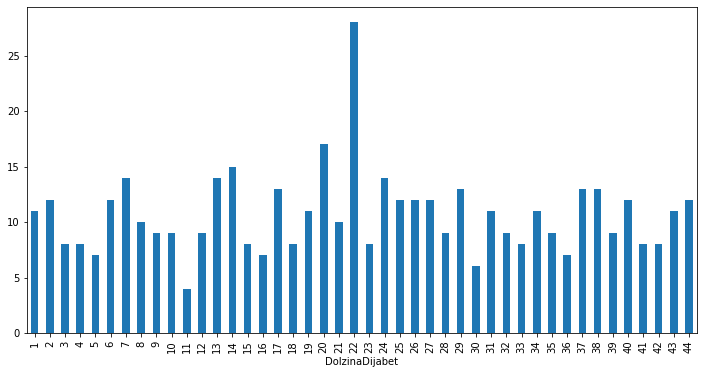

In [42]:
var2 = df.loc[df['DijabetRetin'] == 1.0]
var3 = var2.groupby(['DolzinaDijabet'])['DijabetRetin'].count().plot(kind = 'bar', figsize = (12,6))
plt.show()
# MOST PATIENTS WITH RETINOPATHY HAVE DIABETES FOR 22 YEARS

# grouped = df.groupby(['DolzinaDijabet', 'DijabetRetin']).filter(lambda x: x['DijabetRetin'].isin([1]).all())
# grouped
#df['DolzinaDijabet'].value_counts().idxmax()

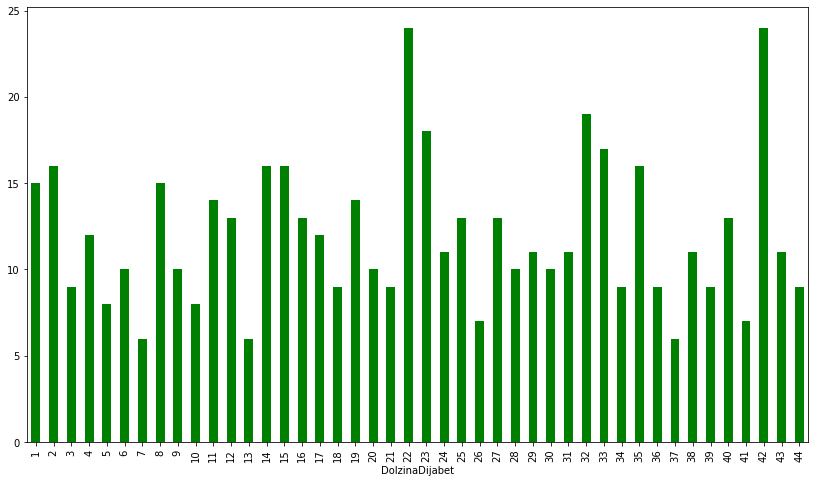

In [43]:
var4 = df.loc[df['DijabetRetin'] == 0.0]
var5 = var4.groupby(['DolzinaDijabet'])['DijabetRetin'].count().plot(kind = 'bar', figsize = (14,8),linewidth = 5, color = 'Green')
plt.show()

---

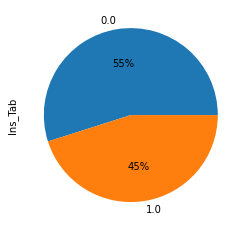

In [44]:
# PATIENTS WITH RETINOPATHY WHO TAKE INSULIN

var6 = df[df['Ins_Tab'] == 0.0]
var7 = var6.groupby(['DijabetRetin'])['Ins_Tab'].count().plot(kind = 'pie', autopct = '%1.0f%%')
plt.show()

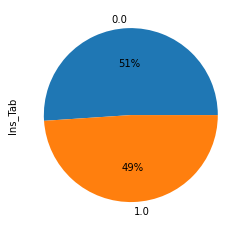

In [45]:
# PATIENTS WITH RETINOPATHY WHO TAKE TABLETS

var8 = df[df['Ins_Tab'] == 1.0]
var9 = var8.groupby(['DijabetRetin'])['Ins_Tab'].count().plot(kind = 'pie', autopct = '%1.0f%%')
plt.show()

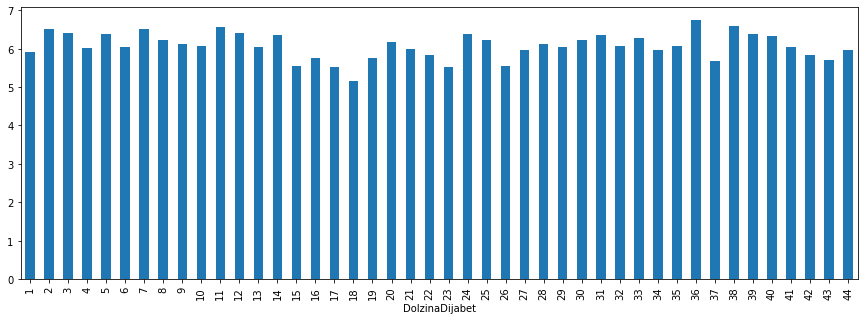

In [46]:
# PATIENTS GLUCOSE LEVELS AND YEARS SINCE DIAGNOSIS 

x = df.groupby(['DolzinaDijabet'])['Nivo_Glukoza'].mean()
x.plot(kind = 'bar', figsize = (15,5))
plt.show()

In [47]:
a = df.groupby(['DolzinaDijabet', 'DijabetRetin']).filter(lambda x: x['DijabetRetin'].isin([0]).all())
a.mean()

ID                503.117202
DolzinaDijabet     22.633270
Tromesecen_A1C      6.414877
Ins_Tab             0.502836
Nivo_Glukoza        6.144348
DijabetRetin        0.000000
dtype: float64

In [48]:
df.head(10)

,ID,DolzinaDijabet,Tromesecen_A1C,Ins_Tab,Nivo_Glukoza,DijabetRetin
0,0,3,9.52,0.0,1.75,1.0
1,1,40,6.40,0.0,6.42,1.0
2,2,38,7.08,0.0,7.01,0.0
3,3,16,4.40,1.0,5.61,0.0
4,4,17,4.75,1.0,4.92,1.0
5,5,13,5.86,0.0,9.50,1.0
6,6,23,9.52,0.0,7.45,1.0
7,7,21,3.30,1.0,5.08,1.0
8,8,13,8.10,0.0,4.55,1.0
9,9,19,2.32,1.0,7.34,1.0


In [49]:
# PATIENT WITH MOST YEARS WITH DIABETES 

df['DolzinaDijabet'].max()

44

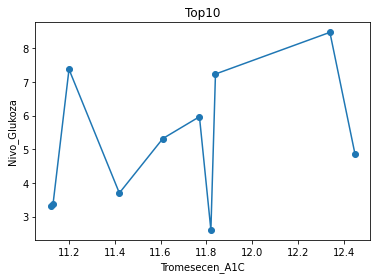

In [50]:
# GROUPING BY A1C LEVELS AND GLUCOSE LEVELS; TOP 10 RESULTS

cc = df.sort_values('Tromesecen_A1C', ascending=False)
top12 = cc.head(10)
plt.plot(top12['Tromesecen_A1C'], top12['Nivo_Glukoza'], marker='o')
plt.xlabel('Tromesecen_A1C')
plt.ylabel('Nivo_Glukoza')
plt.title('Top10')
plt.show()

In [51]:
# COLUMNS RENAMING 

df.rename(columns = {'Tromesecen_A1C' : 'A1C'}, inplace=True)
df.rename(columns={'DolzinaDijabet' : 'DolzinaDB'}, inplace=True)
df.rename(columns={'Nivo_Glukoza' : 'Glukoza'}, inplace=True)

In [52]:
# SELECTING ONLY THE PATIENTS WITH GLUCOSE HIGHER THAN 10 

glk = (df['Glukoza'] > 10.0).sum()
print(f"Number of rows with value higher than 10.0 is: {glk}")

Number of rows with value higher than 10.0 is: 26


In [53]:
# FILTERING NUMBER OF PATIENTS WHO DON'T HAVE RETINOPATHY AND HAVE DIABETES FOR OVER 40 YEARS

x1 = df[(df['DolzinaDB'] >= 40) 
   & (df['DijabetRetin'] == 0.0)].groupby(['DolzinaDB', 'DijabetRetin'])
x1.size()

DolzinaDB  DijabetRetin
40         0.0             13
41         0.0              7
42         0.0             24
43         0.0             11
44         0.0              9
dtype: int64

In [9]:
# GROUPING PATIENTS WHO TAKE INSLUIN AND HAVE GLUCOSE HIGHER THAN OR 5 
# WITH THIS WE CAN SEE HOW MANY OF THE PATIENTS WITH HIGHER GLUCOSE ARE ON INSULIN THERAPY

df[(df['Ins_Tab'] == 0.0) & (df['Glukoza'] >= 5)].shape[0]

In [8]:
# NUMBER OF PATIENTS MEETING THE CONDITION, TAKING TABLETS AND HAVING GLUCOSE LEVEL OF 5 OR HIGHER; 
# WITH THIS WE CAN SEE HOW MANY OF THE PATIENTS WITH HIGHER GLUCOSE ARE ON TABLET THERAPY

df[(df['Ins_Tab'] == 1.0) & (df['Glukoza'] >= 5)].shape[0]

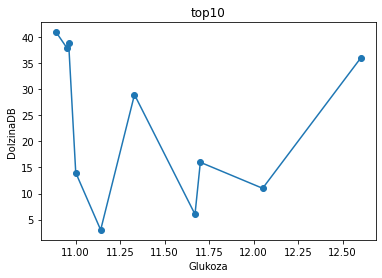

<Figure size 1440x720 with 0 Axes>

In [56]:
# GROUPING PATIENTS BY THE DURATION OF THE DISEASE AND THE GLUCOSE LEVELS

glukoza = df.sort_values('Glukoza', ascending=False)
top10 = glukoza.head(10)
plt.plot(top10['Glukoza'], top10['DolzinaDB'], marker = 'o')
plt.xlabel('Glukoza')
plt.ylabel('DolzinaDB')
plt.title('top10')
plt.figure(figsize=(20,10))
plt.show()

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            1000 non-null   int64  
 1   DolzinaDB     1000 non-null   int32  
 2   A1C           1000 non-null   float64
 3   Ins_Tab       1000 non-null   float64
 4   Glukoza       1000 non-null   float64
 5   DijabetRetin  1000 non-null   float64
dtypes: float64(4), int32(1), int64(1)
memory usage: 43.1 KB
